# S17351 gap 与微单元饱和验证

## tl;dr

两次运行使用同一个 gamma 输入、同一个随机种子，并且都设置 `nsb.enabled=false`。第一遍直接使用数据表 PDE 并关闭微单元占用饱和；第二遍开启无恢复饱和。两遍得到完全相同的 4,247 个 primary p.e.。本次低占用 gamma 中没有重复命中同一微单元，因此两遍均为 4,247 个 fired p.e.；重复命中行为由 C++ 单元测试覆盖。

## Context & Methods

S17351 按规格书建模为 2×4 通道；每通道 6.6×3.2 mm²、264×128 个 25 μm pitch 微单元，通道间隔 0.2 mm。厂家 PDE 直接使用；25 μm pitch 只用于微单元索引和占用饱和，不假设单元内部感光区的位置分布。

In [1]:
# Cell 1 — 所有可修改参数
from pathlib import Path
import math
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "electronics_chain_v2":
    NOTEBOOK_DIR = (
        NOTEBOOK_DIR
        / "validation"
        / "electronics_chain_v2"
    ).resolve()

VALIDATION_ROOT = NOTEBOOK_DIR / "validation_outputs"
GAP_RUN_DIR = VALIDATION_ROOT / "s17351_gap_only"
SATURATION_RUN_DIR = VALIDATION_ROOT / "s17351_saturation"
OUTPUT_DIR = VALIDATION_ROOT / "s17351_gap_saturation_figures"

# 可在这里改为任意有信号的 event/telescope/pixel。
EVENT_ID = 102
TELESCOPE_ID = 12
PIXEL_ID = 174

SENSOR_SIZE_MM = 13.4
CHANNEL_SIZE_X_MM = 6.6
CHANNEL_SIZE_Y_MM = 3.2
CHANNEL_GAP_MM = 0.2
PITCH_MM = 0.025
ZOOM_HALF_WIDTH_MM = 0.14

FIRED_COLOR = "#1677b8"
GAP_COLOR = "#e58b21"
CHANNEL_GAP_COLOR = "#8558a5"
SATURATION_COLOR = "#c83e4d"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Gap run:", GAP_RUN_DIR)
print("Saturation run:", SATURATION_RUN_DIR)
print("Selected event/telescope/pixel:", EVENT_ID, TELESCOPE_ID, PIXEL_ID)

Gap run: /home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_only
Saturation run: /home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_saturation
Selected event/telescope/pixel: 102 12 174


## Data

读取两次程序输出，并先验证两次运行的输入 p.e. 序列一致且不含 NSB。

In [2]:
def load_run(folder):
    root_file = uproot.open(folder / "lact_events.root")
    decisions = root_file["microcell_decisions"].arrays(library="pd")
    collector = pd.read_csv(folder / "collector_photons.csv")
    return decisions, collector

gap_decisions, gap_collector = load_run(GAP_RUN_DIR)
sat_decisions, sat_collector = load_run(SATURATION_RUN_DIR)

identity_columns = [
    "event_id", "telescope_id", "pixel_id", "time_ns",
    "sensor_x_m", "sensor_y_m", "grid_column", "grid_row",
    "channel_id", "microcell_id", "origin",
]
assert gap_decisions[identity_columns].equals(
    sat_decisions[identity_columns]
), "两次运行的 primary p.e. 序列不一致"
assert set(gap_decisions["origin"].unique()) == {0}
assert set(sat_decisions["origin"].unique()) == {0}
assert int(gap_decisions["saturation_rejected"].sum()) == 0

summary = pd.DataFrame(
    [
        {
            "run": "gap only",
            "collector candidates": len(gap_collector),
            "channel-gap rejected": int(
                gap_collector["sipm_channel_gap_rejected"].sum()
            ),
            "primary p.e.": len(gap_decisions),
            "fired p.e.": int(gap_decisions["fired"].sum()),
            "saturation rejected": int(
                gap_decisions["saturation_rejected"].sum()
            ),
        },
        {
            "run": "gap + saturation",
            "collector candidates": len(sat_collector),
            "channel-gap rejected": int(
                sat_collector["sipm_channel_gap_rejected"].sum()
            ),
            "primary p.e.": len(sat_decisions),
            "fired p.e.": int(sat_decisions["fired"].sum()),
            "saturation rejected": int(
                sat_decisions["saturation_rejected"].sum()
            ),
        },
    ]
)
display(summary)
print("NSB p.e. = 0；两遍 primary p.e. 序列逐项完全一致。")

,run,collector candidates,channel-gap rejected,primary p.e.,fired p.e.,saturation rejected
0,gap only,5030,361,4247,4247,0
1,gap + saturation,5030,361,4247,4247,0


NSB p.e. = 0；两遍 primary p.e. 序列逐项完全一致。


## Results

下面两张图都选择同一个 event/telescope/pixel。灰色底表示非感光区域，橙色空心圆表示 gap rejection，红色 × 表示已被占用微单元造成的 saturation rejection。

In [3]:
def select_pixel(frame):
    return frame[
        (frame["event_id"] == EVENT_ID)
        & (frame["telescope_id"] == TELESCOPE_ID)
        & (frame["pixel_id"] == PIXEL_ID)
    ].copy()


def draw_device(ax):
    half = 0.5 * SENSOR_SIZE_MM
    ax.add_patch(
        Rectangle(
            (-half, -half),
            SENSOR_SIZE_MM,
            SENSOR_SIZE_MM,
            facecolor="0.91",
            edgecolor="0.25",
            linewidth=1.2,
            zorder=0,
        )
    )
    for column in range(2):
        for row_bottom in range(4):
            x0 = -half + column * (CHANNEL_SIZE_X_MM + CHANNEL_GAP_MM)
            y0 = -half + row_bottom * (CHANNEL_SIZE_Y_MM + CHANNEL_GAP_MM)
            ax.add_patch(
                Rectangle(
                    (x0, y0),
                    CHANNEL_SIZE_X_MM,
                    CHANNEL_SIZE_Y_MM,
                    facecolor="white",
                    edgecolor="0.55",
                    linewidth=0.8,
                    zorder=1,
                )
            )
            row_top = 3 - row_bottom
            label = f"A-{row_top + 1}" if column == 1 else f"B-{row_top + 1}"
            ax.text(
                x0 + CHANNEL_SIZE_X_MM / 2,
                y0 + CHANNEL_SIZE_Y_MM / 2,
                label,
                ha="center",
                va="center",
                color="0.72",
                fontsize=9,
                zorder=1,
            )
    ax.set_xlim(-half - 0.2, half + 0.2)
    ax.set_ylim(-half - 0.2, half + 0.2)
    ax.set_aspect("equal")
    ax.set_xlabel("SiPM local x (mm)")
    ax.set_ylabel("SiPM local y (mm)")


def channel_local_geometry(x_mm, y_mm):
    half = 0.5 * SENSOR_SIZE_MM
    local_x = x_mm + half
    local_y = y_mm + half
    tile_x = CHANNEL_SIZE_X_MM + CHANNEL_GAP_MM
    tile_y = CHANNEL_SIZE_Y_MM + CHANNEL_GAP_MM
    channel_column = min(1, max(0, int(math.floor(local_x / tile_x))))
    channel_row = min(3, max(0, int(math.floor(local_y / tile_y))))
    x0 = -half + channel_column * tile_x
    y0 = -half + channel_row * tile_y
    return x0, y0


def draw_microcell_zoom(ax, center_x_mm, center_y_mm):
    x0_channel, y0_channel = channel_local_geometry(
        center_x_mm, center_y_mm
    )
    x_min = center_x_mm - ZOOM_HALF_WIDTH_MM
    x_max = center_x_mm + ZOOM_HALF_WIDTH_MM
    y_min = center_y_mm - ZOOM_HALF_WIDTH_MM
    y_max = center_y_mm + ZOOM_HALF_WIDTH_MM

    first_column = max(
        0, int(math.floor((x_min - x0_channel) / PITCH_MM)) - 1
    )
    last_column = min(
        263, int(math.floor((x_max - x0_channel) / PITCH_MM)) + 1
    )
    first_row = max(
        0, int(math.floor((y_min - y0_channel) / PITCH_MM)) - 1
    )
    last_row = min(
        127, int(math.floor((y_max - y0_channel) / PITCH_MM)) + 1
    )
    ax.set_facecolor("white")
    for column in range(first_column, last_column + 1):
        for row in range(first_row, last_row + 1):
            cell_x = x0_channel + column * PITCH_MM
            cell_y = y0_channel + row * PITCH_MM
            ax.add_patch(
                Rectangle(
                    (cell_x, cell_y),
                    PITCH_MM,
                    PITCH_MM,
                    facecolor="0.96",
                    edgecolor="0.52",
                    linewidth=0.55,
                    zorder=1,
                )
            )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.set_xlabel("SiPM local x (mm)")
    ax.set_ylabel("SiPM local y (mm)")


def add_gap_points(ax, collector, full=False):
    channel_gap = collector[collector["sipm_channel_gap_rejected"] == 1]
    size = 48 if full else 80
    ax.scatter(
        channel_gap["exit_x_m"] * 1e3,
        channel_gap["exit_y_m"] * 1e3,
        s=size,
        marker="s",
        facecolors="none",
        edgecolors=CHANNEL_GAP_COLOR,
        linewidths=1.7,
        label="channel gap rejected",
        zorder=6,
    )


def add_decision_points(ax, decisions, include_saturation):
    fired = decisions[decisions["fired"]]
    ax.scatter(
        fired["sensor_x_m"] * 1e3,
        fired["sensor_y_m"] * 1e3,
        s=30,
        c=FIRED_COLOR,
        edgecolors="white",
        linewidths=0.45,
        label="fired p.e.",
        zorder=7,
    )
    if include_saturation:
        saturated = decisions[decisions["saturation_rejected"]]
        ax.scatter(
            saturated["sensor_x_m"] * 1e3,
            saturated["sensor_y_m"] * 1e3,
            s=110,
            marker="x",
            c=SATURATION_COLOR,
            linewidths=2.1,
            label="saturation rejected",
            zorder=9,
        )

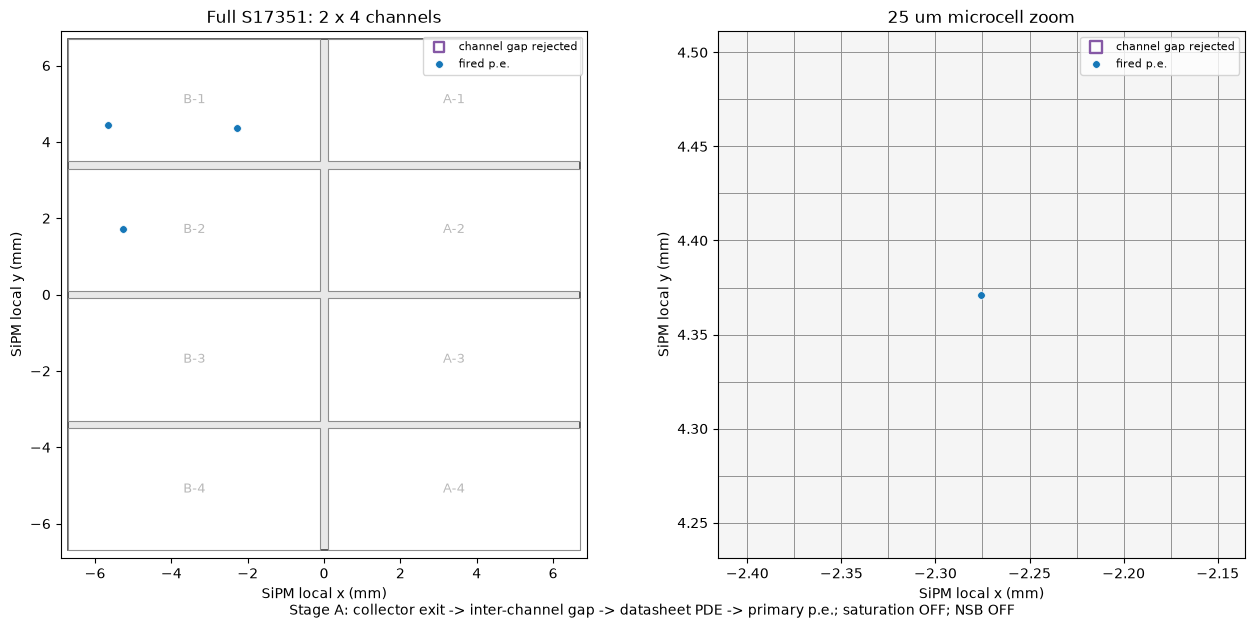

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_gap_only_no_nsb.png


In [4]:
# 图 1：直接 PDE 阶段；无 NSB，微单元占用饱和关闭
gap_pixel_decisions = select_pixel(gap_decisions)
gap_pixel_collector = select_pixel(gap_collector)
gap_zoom_rows = gap_pixel_decisions[gap_pixel_decisions["fired"]]
assert len(gap_zoom_rows) > 0
gap_zoom_x = float(gap_zoom_rows.iloc[0]["sensor_x_m"] * 1e3)
gap_zoom_y = float(gap_zoom_rows.iloc[0]["sensor_y_m"] * 1e3)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
draw_device(axes[0])
add_gap_points(axes[0], gap_pixel_collector, full=True)
add_decision_points(axes[0], gap_pixel_decisions, include_saturation=False)
axes[0].set_title("Full S17351: 2 x 4 channels")
axes[0].legend(loc="upper right", fontsize=8)

draw_microcell_zoom(axes[1], gap_zoom_x, gap_zoom_y)
add_gap_points(axes[1], gap_pixel_collector)
add_decision_points(axes[1], gap_pixel_decisions, include_saturation=False)
axes[1].set_title("25 um microcell zoom")
axes[1].legend(loc="upper right", fontsize=8)

fig.text(
    0.5,
    -0.015,
    "Stage A: collector exit -> inter-channel gap -> "
    "datasheet PDE -> primary p.e.; "
    "saturation OFF; NSB OFF",
    ha="center",
)
gap_figure_path = OUTPUT_DIR / "s17351_gap_only_no_nsb.png"
fig.savefig(gap_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(gap_figure_path)

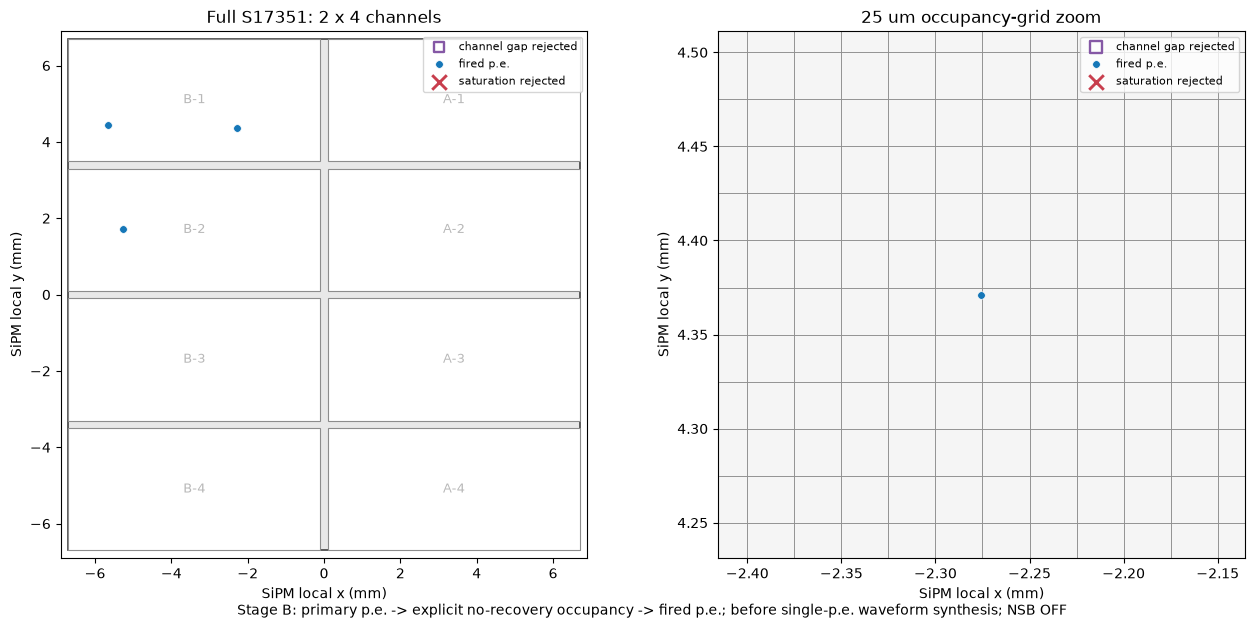

/home/hyy/codex_tmp/lact_electronics_v2_build_20260731/validation/electronics_chain_v2/validation_outputs/s17351_gap_saturation_figures/s17351_saturation_no_nsb.png


In [5]:
# 图 2：微单元占用饱和阶段；无 NSB
sat_pixel_decisions = select_pixel(sat_decisions)
sat_pixel_collector = select_pixel(sat_collector)
sat_zoom_rows = sat_pixel_decisions[
    sat_pixel_decisions["saturation_rejected"]
]
if len(sat_zoom_rows) == 0:
    sat_zoom_rows = sat_pixel_decisions[sat_pixel_decisions["fired"]]
assert len(sat_zoom_rows) > 0
sat_zoom_x = float(sat_zoom_rows.iloc[0]["sensor_x_m"] * 1e3)
sat_zoom_y = float(sat_zoom_rows.iloc[0]["sensor_y_m"] * 1e3)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
draw_device(axes[0])
add_gap_points(axes[0], sat_pixel_collector, full=True)
add_decision_points(axes[0], sat_pixel_decisions, include_saturation=True)
axes[0].set_title("Full S17351: 2 x 4 channels")
axes[0].legend(loc="upper right", fontsize=8)

draw_microcell_zoom(axes[1], sat_zoom_x, sat_zoom_y)
add_gap_points(axes[1], sat_pixel_collector)
add_decision_points(axes[1], sat_pixel_decisions, include_saturation=True)
axes[1].set_title("25 um occupancy-grid zoom")
axes[1].legend(loc="upper right", fontsize=8)

fig.text(
    0.5,
    -0.015,
    "Stage B: primary p.e. -> explicit no-recovery occupancy "
    "-> fired p.e.; before single-p.e. waveform synthesis; NSB OFF",
    ha="center",
)
saturation_figure_path = OUTPUT_DIR / "s17351_saturation_no_nsb.png"
fig.savefig(saturation_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(saturation_figure_path)

## Takeaways

- 图 1 是波形之前的直接 PDE 阶段；25 μm 网格只表示微单元索引，不表示未知的单元内部感光区。
- 图 2 是下一步微单元占用阶段：蓝点是 fired p.e.，红色 × 是同一事件内第二次命中同一微单元而被拒绝的 p.e.
- 两次运行都没有 NSB；NSB-only 仍可用独立电子学入口单独生成并在后续波形层叠加。
- `primary_pe_hits`、`microcell_decisions` 和 collector photon debug 只在验证配置中保存；正式配置默认关闭这些逐 hit 输出。